# EuroSAT RGB (3-channel) data exploration

This notebook explores the RGB EuroSAT release on Hugging Face blanchon/EuroSAT_RGB. The dataset has 10 land-cover classes, images in 64×64 patches, and the same 60/20/20 train/validation/test splits as the multispectral dataset. This is the baseline input modality before we compare against 13-band Sentinel-2 stacks.

For the multispectral EDA, see [`02_data_exploration_multispectral.ipynb`](02_data_exploration_multispectral.ipynb).

## Setup

Figures go to `figures/` from whatever directory you run the notebook in (I run from repo root so they match [`notebooks/figures/`](figures/)). Training uses ImageNet norm for RGB in [`train.py`](../train.py); the prints below are still raw uint8 stats.

In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

RNG = np.random.default_rng(42)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 200,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "figure.figsize": (8, 4.5),
        "image.cmap": "viridis",
    }
)

/Users/david/eurosat/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load dataset and schema

Each row has `image`, integer `label`, and `filename` (e.g. `AnnualCrop_1.tif`). The `image` field is a PIL RGB image when loaded through `datasets`.

In [2]:
EuroSAT_RGB = load_dataset("blanchon/EuroSAT_RGB")
print(EuroSAT_RGB)
label_names = EuroSAT_RGB["train"].features["label"].names
num_classes = EuroSAT_RGB["train"].features["label"].num_classes
print("Classes:", label_names)
print("num_classes:", num_classes)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})
Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']
num_classes: 10


The release is already split into **train**, **validation**, and **test**. We use train for fitting, validation for hyperparameters / early stopping, and test for a final unbiased estimate.

### Array shape and dtype

After `numpy` conversion, patches are uint8 in HWC (Height, Width, Channel) order, typically in [0, 255] before linear rescaling to [0, 1] for display or model input.

In [3]:
for i in range(3):
    ex = EuroSAT_RGB["train"][i]
    arr = np.asarray(ex["image"])
    print(
        i,
        ex["filename"],
        arr.shape,
        arr.dtype,
        int(arr.min()),
        int(arr.max()),
        "label:", label_names[ex["label"]],
    )

0 AnnualCrop_1.tif (64, 64, 3) uint8 75 195 label: Annual Crop
1 AnnualCrop_10.tif (64, 64, 3) uint8 33 202 label: Annual Crop
2 AnnualCrop_100.tif (64, 64, 3) uint8 55 204 label: Annual Crop


## Class distribution (train split)

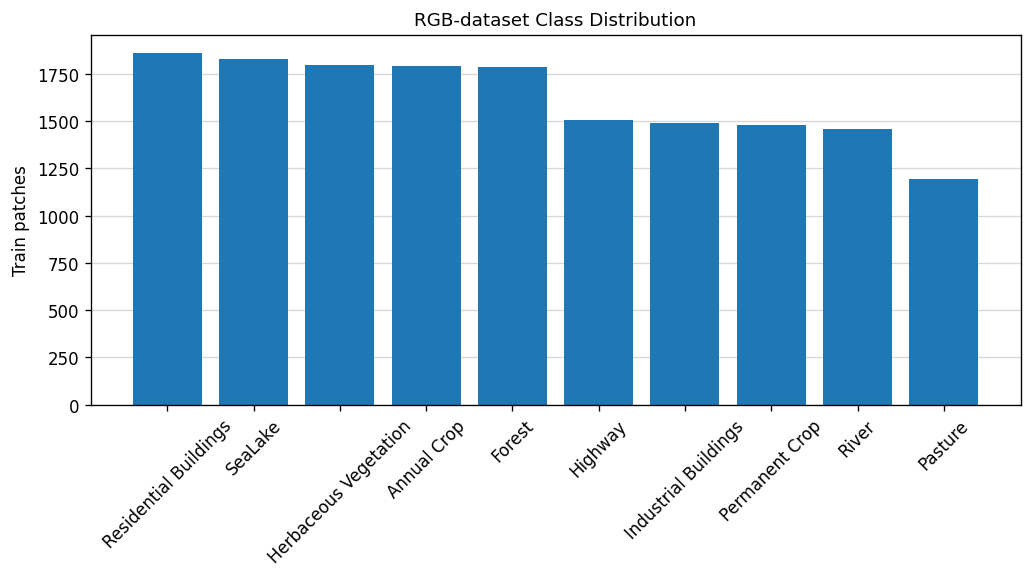

In [19]:
labels = EuroSAT_RGB["train"]["label"]
counts = Counter(labels)
order = sorted(counts, key=lambda k: (-counts[k], k))
names = [label_names[i] for i in order]
vals = [counts[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 4))
ax.grid(axis="y", alpha=0.5)
ax.bar(names, vals, zorder=2)
ax.set_ylabel("Train patches")
ax.set_title("RGB-dataset Class Distribution")
ax.tick_params(axis="x", rotation=45)
fig.savefig(FIG_DIR / "rgb_class_distribution_train.png", bbox_inches="tight")
plt.show()

Pasture is the smallest class, then Highway, Industrial Buildings, Permanent Crop, and River—but every class still has on the order of 1.3k–1.8k training patches, so the split is roughly balanced and I am not planning class weights or oversampling unless a later experiment shows instability.

## Visual examples

Quick sanity check of what the model actually sees. I pull the first training example for each label (deterministic, cheap) and lay them out in a 2×5 grid.

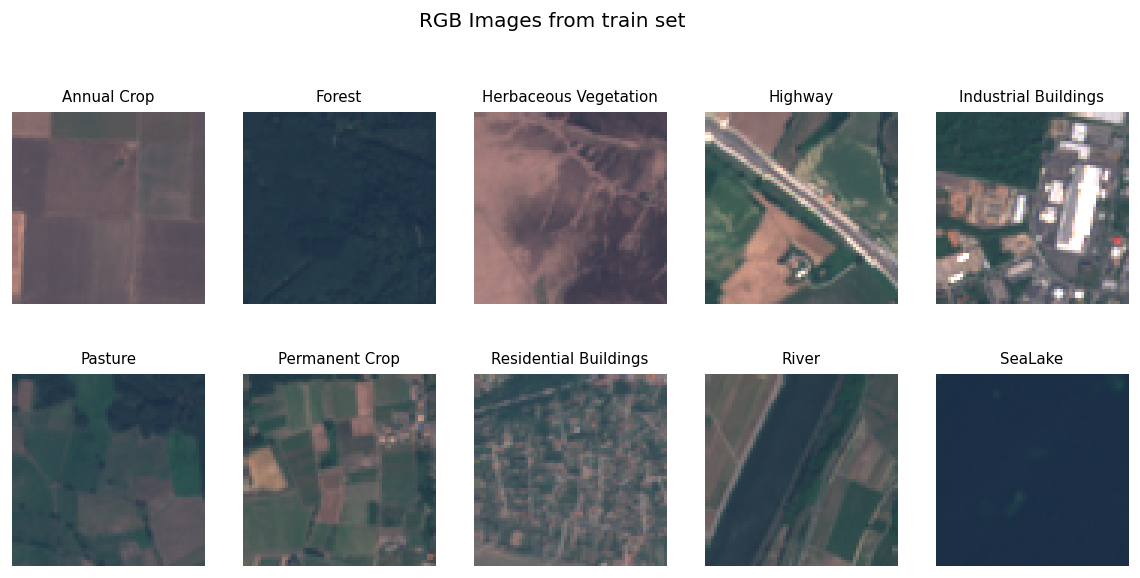

In [21]:
first_by_label = {}
for ex in EuroSAT_RGB["train"]:
    k = ex["label"]
    if k not in first_by_label:
        first_by_label[k] = ex
    if len(first_by_label) == num_classes:
        break

fig, axes = plt.subplots(2, 5, figsize=(12, 5.2))
for i, ax in enumerate(axes.flat):
    im = first_by_label[i]["image"]
    ax.imshow(im)
    ax.set_title(label_names[i], fontsize=9)
    ax.axis("off")
fig.suptitle("RGB Images from train set", y=1.02)
fig.savefig(FIG_DIR / "rgb_sample_grid.png", bbox_inches="tight")
plt.show()

At 64×64, Forest and Sea/Lake are easy to confuse visually, as are Pasture and Permanent Crop. Confusion between these pairs in a confusion matrix would not be surprising.